# ============= INFERENCE NOTEBOOK =============

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

import librosa as lb
import librosa.feature as lf
import librosa.display as ld

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms

from torch.utils.data import Dataset,DataLoader

from tqdm import tqdm
import matplotlib.pyplot as plt

SR = 22050
DURATION = 30

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("kgg_key")
secret_value_1 = user_secrets.get_secret("kgg_user")


#============ Check for GPU availability ==============================#
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Using device: {device}")

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    print("GPU is available.Setting RANDOM_SEED .... ")
        # setting for both CPU and GPU
    torch.cuda.manual_seed_all(RANDOM_SEED)
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("   Running on CPU")
print("\n✅ Environment setup complete!")

import warnings
warnings.filterwarnings("ignore")

🚀 Using device: cuda
GPU is available.Setting RANDOM_SEED .... 
   GPU: Tesla T4
   Memory: 14.6 GB

✅ Environment setup complete!


Your First Neural Network & CNNs!

* Learn PyTorch basics: Tensors, Dataset (custom loader for training), DataLoader.
* Convert audio to 2D/1D Mel-Spectrograms.
* Build a simple CNN (Convolutional Neural Network)/NN (Neural Network) to process the spectrograms.
* Implement training loop, loss, optimizer, and wandb logging.
* Train and evaluate your CNN/NN (Neural Network)model.

# Definition

## 1. Utility

In [3]:
def extract_paths_ids():
    test_mels_paths = []
    count = 0
    root_to_test_mels = "/kaggle/input/datasets/akashkumbhakar/test-mel-3020"
    test_csv = pd.read_csv("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv")
    for song_id in test_csv['id']:
        mel_file = f"mel_{song_id}.npy"
        path = os.path.join(root_to_test_mels,mel_file)
        test_mels_paths.append((song_id,path))
        count += 1
    print("Total paths (music files) : ", count)
    return test_mels_paths

def idx_to_genre(targets):
    id_to_genre = {0:'blues', 1:'classical', 2:'country', 3:'disco', 4:'hiphop',5:'jazz', 6:'metal', 7:'pop', 8:'reggae', 9:'rock'}
    y = [id_to_genre[id] for id in targets]

    return y    

## 2. Dataset and DataLoader

In [4]:
class MelDataset(Dataset):
    def __init__(self,paths,transform):  # paths : List[(path,label)]
        self.paths = paths
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self,idx):
        mel_arr = np.load(self.paths[idx][1])
        #mel = torch.from_numpy(mel).float()
        mel = self.transform(mel_arr)
        ids = torch.tensor(self.paths[idx][0], dtype=torch.long)
        return ids,mel  

data_transformer = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[-45.60], std=[16.60])
])

config = {
    "batch_size" : 64
}

test_paths = extract_paths_ids()
test_dataset = MelDataset(test_paths,data_transformer)
test_loader = DataLoader(
    test_dataset,
    batch_size=config['batch_size'],
    shuffle=False,
    num_workers=4,
    persistent_workers=True,
    pin_memory=True
)

print(f"Size of Test Dataloader : {len(test_loader)}")
print("✅")

Total paths (music files) :  3020
Size of Test Dataloader : 48
✅


## 3. Model

In [7]:
"""class MelCNN(nn.Module):
    def __init__(self, num_classes):
        super(MelCNN, self).__init__()
        # First convolutional block
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2,2)

        self.global_pool = nn.AdaptiveAvgPool2d((1,1))
        # Fully connected head
        self.fc1 = nn.Linear(64, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):

        # (B,1,64,647)

        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # 
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x"""

from torchvision.models import resnet18,ResNet18_Weights
res_net = resnet18( progress=False)
res_net

class MelResNet18(nn.Module):
    def __init__(self,res_net,num_class):
        super().__init__()
        # reshapeing pretrained weights to channel=1
        #old_weights = res_net.conv1.weight
        #res_net.conv1.weight.data = old_weights.mean(dim=1, keepdim=True)
        
        res_net.conv1 = nn.Conv2d(1,64,kernel_size=(3, 3), stride=1, padding=1, bias=False)
        #for param in res_net.parameters():
            #param.requires_grad = False

        res_net.fc = nn.Linear(res_net.fc.in_features,128)
        self.resnet = res_net
        
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_class)
        
    def forward(self, x):
        x = self.resnet(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x
_="""

class MelCLSTM(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        #self.cnn =  nn.Sequential()
        # First convolutional block
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d(2,2)
        
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(2,2)
        
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.pool3 = nn.MaxPool2d(2,2)


        #self.global_pool = nn.AdaptiveAvgPool2d((1,1))
        # Fully connected head
        #self.fc1 = nn.Linear(64, 128)
        #self.dropout = nn.Dropout(0.5)
        #self.fc2 = nn.Linear(128, num_classes)
        self.lstm = nn.LSTM(
            1024,
            hidden_size=64,
            batch_first=True,
            num_layers=1,
            bidirectional=True
        )
        self.fc = nn.Linear(64*2, num_classes)

    def forward(self, x):

        # INPUT :  (B,1,128,647)

        x = self.pool1(F.relu(self.bn1(self.conv1(x))))  
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        #SHAPE Here : (B,64,16,80)
        #x = self.global_pool(x)
        #x = x.view(x.size(0), -1)
        #x = F.relu(self.fc1(x))
        #x = self.dropout(x)
        #x = self.fc2(x)
        batch,channel,freq,time = x.size()
        #print(batch,channel,freq,time)
        x_rnn_in = x.permute(0, 3, 1, 2).reshape(batch,time,channel*freq)
        x_rnn_out, _hc= self.lstm(x_rnn_in)
        pooled_x,_ = torch.max(x_rnn_out, dim=1)
        out_logit = self.fc(pooled_x)        
        return out_logit
"""


## 5. Evaluation

In [8]:
def evaluation(model,test_loader):
    model.to(device)
    model.eval()
    all_ids = []
    all_pred = []
    with torch.no_grad():
        for ids,mels in tqdm(test_loader, desc="Evaluating"):
            mels = mels.to(device,non_blocking=True)
            
            output = model(mels)

            probs = torch.softmax(output,dim=1) 
            predicted_y = torch.argmax(probs,dim=1)

            all_pred.append(predicted_y)
            all_ids.append(ids)
        all_pred = torch.cat(all_pred,dim=0).cpu().numpy()
        all_ids = torch.cat(all_ids,dim=0).cpu().numpy()
        
        print(all_pred.shape)
        print(all_ids.shape)

        return all_pred,all_ids

# Loading models

In [9]:
import kagglehub
# Download latest version
path = kagglehub.model_download("akashkumbhakar/resnet-finetune/pyTorch/default")
print("Path to model files:", path)

Path to model files: /kaggle/input/models/akashkumbhakar/resnet-finetune/pytorch/default/1


# Evaluation

In [11]:
model = MelResNet18(res_net,10)
checkpoint_dict = torch.load(
    f"{path}/checkpoint.pth",
    map_location=torch.device(device))
model.load_state_dict(checkpoint_dict['model_state_dict'])
all_pred,all_ids = evaluation(model,test_loader)

Evaluating: 100%|██████████| 48/48 [00:15<00:00,  3.01it/s]

(3020,)
(3020,)


# Saving submission

## - Loading sample_submission file

In [12]:
sample_dir = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/sample_submission.csv"
sample_sub = pd.read_csv(sample_dir)
print("✅ Sample Submission dataset loaded.")
sample_sub['genre']

✅ Sample Submission dataset loaded.


0            jazz
1           blues
2       classical
3             pop
4           disco
          ...    
3015          pop
3016        blues
3017         jazz
3018         rock
3019       reggae
Name: genre, Length: 3020, dtype: object

In [13]:
y_pred = idx_to_genre(all_pred)
y_pred[:5]

['pop', 'reggae', 'disco', 'hiphop', 'country']

In [14]:
sample_sub['genre'] = y_pred

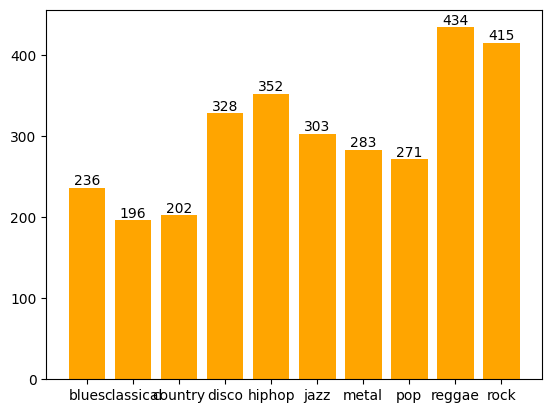

In [15]:
pred = sample_sub['genre'].value_counts()

genres = ['blues', 'classical', 'country', 'disco', 'hiphop','jazz', 'metal', 'pop', 'reggae', 'rock'] 
pred_count = [pred[g] for g in genres]

bars = plt.bar(genres,pred_count,color='orange')
plt.bar_label(bars,label=pred_count)
plt.xticks(rotation=0)
plt.show()


In [16]:
sample_sub.to_csv('submission.csv',index=False)
if os.path.exists("/kaggle/working/submission.csv"):
    print("✅ Submission.csv created successfully.")

✅ Submission.csv created successfully.
